# Nowcasting del IMACEC — Modelos Lineales Penalizados
## Variación Porcentual Interanual | Horizonte h=1 | LassoCV, RidgeCV, ElasticNetCV

**Estructura del notebook:**
1. Librerías y configuración
2. Carga y exploración de datos
3. Ingeniería de features (transformaciones diferenciadas por tipo de variable)
4. Preprocesamiento (Pipeline con StandardScaler)
5. Benchmarks (Naive y Expectativas de mercado)
6. Modelado con backtesting (expanding window)
7. Evaluación (MAE, RMSE, R², Directional Accuracy)
8. Interpretabilidad (coeficientes Lasso, Top 15 variables)
9. Visualización de resultados
9b. LassoCV — figuras tesis (OOS, α, residuos)
9c. LassoCV — coeficientes en el tiempo (heatmap / trayectorias)
11. LightGBM (exploratorio) y ensamble
11.6. Diagnóstico de residuos — modelo ensamble (nowcasting)
10. Análisis final y conclusiones

## 1. Librerías y configuración

In [38]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import norm
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan, het_white
from statsmodels.stats.stattools import jarque_bera
from sklearn.neural_network import MLPRegressor
_SUFFIX_RE = re.compile(r'_(yoy|mom|log_diff|level|diff|sa|delta)_L\d+$', re.IGNORECASE)

def _clean_feat_name(name):
    """Elimina el sufijo de transformación (_yoy_L0, _log_diff_L1, etc.) de un nombre de feature."""
    return _SUFFIX_RE.sub('', str(name))

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
np.random.seed(42)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [39]:
HORIZON = 1
MIN_TRAIN = 60
TSCV_SPLITS = 5
ALPHA_GRID = np.logspace(-4, 2, 50)
L1_RATIOS = [0.1, 0.5, 0.7, 0.9, 0.99]

TARGETS_CONFIG = {
    'IMACEC':        {'benchmark_col': 'EXP_IMACEC'}}
# Variables crudas (como en VARIABLE_CONFIG / df_raw) cuyas columnas derivadas NO entran en X
# para un target dado. Para IMACEC no minero se omiten señales muy ligadas a minería / cobre.
EXCLUDE_VARS_FOR_TARGET = {
    'IMACEC':        []
}

# Clasificación de variables por tipo económico, transformación y publication lag
# Cada variable genera 2 lags: pub_lag y pub_lag+1 (excepto IMCE: solo lag 0)
VARIABLE_CONFIG = {
    'actividad': {
        'vars': {
            'IVA':              {'pub_lag': 1},
            'CNC':              {'pub_lag': 1},
            'GWH':              {'pub_lag': 0},
            'INE_MANUFACTURA':  {'pub_lag': 2},
        },
        'transform': 'yoy',
    },
    'financieras': {
        'vars': {
            'DÓLAR_OBS': {'pub_lag': 0},
            'IPSA':      {'pub_lag': 0},
            'WTI':       {'pub_lag': 0},
        },
        'transform': 'log_diff',
    },
    'tasas_nivel': {
        'vars': {'TPM': {'pub_lag': 0}},
        'transform': 'level',
    },
    'tasas_yoy': {
        'vars': {'IPC': {'pub_lag': 1}},
        'transform': 'yoy',
    },
    'expectativas': {
        'vars': {'IMCE': {'pub_lag': 0}},
        'transform': 'level',
        'extra_lag': False,
    },

    'comercio_exterior': {
    'vars': {
        'IMP_CIF': {'pub_lag': 1},
    },
    'transform': 'yoy',
    },
    'mineria': {
    'vars': {
        'INE_MINERO': {'pub_lag': 2},
        'BML':        {'pub_lag': 0}, # Precio del cobre
    },
    'transform': 'yoy', # O log_diff para el BML
    },    
    'google_trends': {
    'vars': {
        'DÓLAR': {'pub_lag': 0},
        'SEGURO_CESANTIA':{'pub_lag': 0},        
        'SUELDO_MINIMO': {'pub_lag': 0},
        'VALOR_UF':{'pub_lag': 0},
    },
    'transform': 'yoy', # O log_diff para el BML
    },
    'global': {
    'vars': {
        'BONO_EEUU': {'pub_lag': 0},
    },
    'transform': 'log_diff',
}
}

BENCHMARK_VARS = ['EXP_IMACEC']

# Target de entrenamiento: 'yoy' (var% interanual nivel) (cambio mes a mes del YoY)
TRAIN_TARGET_SPACE = 'yoy'  # 'yoy'
# Espacio para MAE/RMSE/R²/DM y gráficos (las predicciones se convierten si difiere de TRAIN_TARGET_SPACE)
METRIC_TARGET_SPACE = 'yoy'  # 'yoy'

print('Configuración definida.')

Configuración definida.


In [40]:
df_raw = pd.read_excel('quinta_base.xlsx', sheet_name='Canasta')

df_raw = df_raw.drop(columns=[c for c in df_raw.columns if c.startswith('Columna')], errors='ignore')
df_raw = df_raw.rename(columns={'Periodo': 'fecha'})
df_raw['fecha'] = pd.to_datetime(df_raw['fecha'])
df_raw = df_raw.sort_values('fecha').reset_index(drop=True)

print(f'Shape: {df_raw.shape}')
print(f'Rango temporal: {df_raw["fecha"].min():%Y-%m} → {df_raw["fecha"].max():%Y-%m}')
print(f'\nColumnas ({len(df_raw.columns)}):')
print(list(df_raw.columns))
df_raw.head(3)

Shape: (265, 23)
Rango temporal: 2004-01 → 2026-01

Columnas (23):
['fecha', 'IMACEC', 'DÓLAR_OBS', 'IVA', 'CNC', 'GWH', 'INE_MINERO', 'TPM', 'IMCE', 'BML', 'WTI', 'BONO_EEUU', 'IPSA', 'INE_MANUFACTURA', 'IPC', 'IMP_CIF', 'EXP_IMACEC', 'EXP_IMACEC_NO_MIN', 'IMACEC_NO_MIN', 'VALOR_UF', 'SUELDO_MINIMO', 'SEGURO_CESANTIA', 'DÓLAR']


,fecha,IMACEC,DÓLAR_OBS,IVA,CNC,GWH,INE_MINERO,TPM,IMCE,BML,...,INE_MANUFACTURA,IPC,IMP_CIF,EXP_IMACEC,EXP_IMACEC_NO_MIN,IMACEC_NO_MIN,VALOR_UF,SUELDO_MINIMO,SEGURO_CESANTIA,DÓLAR
0,2004-01-01,56.955084,573.641429,403120.0,60.277920,3930.55221,78.213425,1.869048,61.696945,1.099324,...,77.239521,47.250566,1859.655051,3.5,NaN,52.289829,15,11,6,10
1,2004-02-01,54.856650,584.306000,333215.0,57.590135,3796.23732,77.769290,1.750000,62.639008,1.251715,...,75.529420,47.256334,1549.031894,3.8,NaN,50.485787,10,17,8,9
2,2004-03-01,61.862996,603.912174,369204.0,69.914536,4157.08074,87.266175,1.750000,62.145172,1.364746,...,86.787579,47.453597,1979.738270,3.5,NaN,57.020012,6,14,5,8


In [41]:
print('Valores nulos por columna:')
nulls = df_raw.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else 'Sin nulos.')
print(f'\nEstadísticas descriptivas:')
df_raw.describe().round(2)

Valores nulos por columna:
EXP_IMACEC_NO_MIN    168

Estadísticas descriptivas:


,fecha,IMACEC,DÓLAR_OBS,IVA,CNC,GWH,INE_MINERO,TPM,IMCE,BML,...,INE_MANUFACTURA,IPC,IMP_CIF,EXP_IMACEC,EXP_IMACEC_NO_MIN,IMACEC_NO_MIN,VALOR_UF,SUELDO_MINIMO,SEGURO_CESANTIA,DÓLAR
count,265,265.00,265.00,265.00,265.00,265.00,265.00,265.00,265.00,265.00,...,265.00,265.00,265.00,265.00,97.00,265.00,265.00,265.00,265.00,265.00
mean,2014-12-31 10:46:38.490566144,89.15,652.41,1168409.32,99.52,5748.34,95.16,4.13,50.66,3.14,...,95.49,71.54,5555.88,3.04,2.06,88.62,50.45,31.08,16.11,23.13
min,2004-01-01 00:00:00,54.86,442.94,333215.00,57.50,3796.24,74.93,0.50,31.74,1.10,...,75.53,47.25,1549.03,-16.10,-17.50,50.49,6.00,7.00,3.00,5.00
25%,2009-07-01 00:00:00,74.87,527.44,653395.40,77.47,4778.37,91.05,2.50,43.91,2.60,...,90.99,58.43,4525.31,1.50,-0.40,72.14,29.00,17.00,8.00,10.00
50%,2015-01-01 00:00:00,91.04,623.01,1059506.13,99.96,5879.07,95.28,3.65,51.11,3.18,...,95.87,68.37,5751.92,3.00,2.20,90.99,58.00,28.00,13.00,20.00
75%,2020-07-01 00:00:00,102.05,762.88,1535042.42,113.61,6545.17,100.13,5.14,57.41,3.77,...,100.81,79.59,6760.38,5.00,3.20,102.83,69.00,41.00,21.00,32.00
max,2026-01-01 00:00:00,129.20,1000.76,2806836.51,187.27,7540.50,118.56,11.25,64.43,5.94,...,113.13,109.71,9971.47,16.50,18.00,132.96,100.00,100.00,100.00,100.00
std,NaN,16.50,149.95,616915.56,23.79,1000.92,7.44,2.53,7.64,0.89,...,7.16,17.40,1752.49,3.83,5.88,18.90,23.76,16.88,11.27,15.63


## 3. Ingeniería de features

Se aplican transformaciones diferenciadas según el tipo de variable. Las features se separan en **comunes** (exógenas, compartidas por ambos targets) y **target-específicas** (autorregresivas, propias de cada $y_t$).

### Features comunes (`feature_cols_common`)

| Tipo | Variables | Transformación | Lags |
|------|-----------|---------------|------|
| Actividad real | IVA, CNC, GWH, INE_MINERO, INE_MANUFACTURA, IMP_CIF, BML | Variación interanual | 1, 2, 3, 6, 12 |
| Financieras | DÓLAR_OBS, IPSA, WTI, BONO_EEUU | Log-diferencia (retornos) | 1, 2, 3 |
| Tasas (nivel) | TPM | Nivel | 1, 2, 3, 6 |
| Tasas (YoY) | IPC | Variación interanual | 1, 2, 3, 6 |
| Expectativas | IMCE | Nivel (contemporáneo) | 0 |
| **MA actividad** | IVA, CNC, INE_MANUFACTURA | MA(3), MA(6) de var% interanual | shift(1) |
| **Dummies de eventos** | d_crisis_2008, d_terremoto_27f, d_rebote_27f, d_covid | Binaria (0/1) | — |

> **Dummies:** `d_crisis_2008` (Sep 2008 – Jun 2009), `d_terremoto_27f` (Feb 2010 – Mar 2010), `d_rebote_27f` (Feb 2011 – Abr 2011), `d_covid` (Mar 2020 – Dic 2021).

### Features target-específicas (`feature_cols_target[target]`)

Cada target usa **solo** sus propios rezagos, sin cruzar información con el otro target.

Para **IMACEC no minero**, el vector de features comunes puede **excluir** variables definidas en `EXCLUDE_VARS_FOR_TARGET` en la celda de configuración (por defecto se quitan señales muy ligadas a minería / cobre: `INE_MINERO`, `BML`). IMACEC agregado sigue usando la piscina completa.

| Tipo | Variables | Transformación | Lags |
|------|-----------|---------------|------|
| **Autorregresivas** | $y_t$ (propio target) | Var% interanual rezagada | 1, 3 |
| **Media móvil** | $y_t$ suavizado | MA(3) del target | shift(1) |

### Variable objetivo

$$y_t = \frac{IMACEC_t}{IMACEC_{t-12}} - 1$$

In [42]:
def apply_transform(series, method):
    """Aplica la transformación indicada a una serie temporal."""
    if method == 'yoy':
        return series.pct_change(12) * 100
    elif method == 'log_diff':
        return np.log(series).diff() * 100
    elif method == 'level':
        return series.copy()
    else:
        raise ValueError(f'Transformación desconocida: {method}')


df = pd.DataFrame({'fecha': df_raw['fecha']})

for target_name in TARGETS_CONFIG:
    df[f'{target_name}_yoy'] = df_raw[target_name].pct_change(12) * 100
    df[f'{target_name}_delta'] = df[f'{target_name}_yoy'] - df[f'{target_name}_yoy'].shift(1)

feature_cols_common = []

# ── (A) Features exógenas transformadas con publication lags ──
for group_name, config in VARIABLE_CONFIG.items():
    transform = config['transform']
    add_extra = config.get('extra_lag', False)

    for var, var_cfg in config['vars'].items():
        pub_lag = var_cfg['pub_lag']
        transformed = apply_transform(df_raw[var], transform)

        lags = [pub_lag, pub_lag + 1] if add_extra else [pub_lag]
        for lag in lags:
            col_name = f'{var}_{transform}_L{lag}'
            df[col_name] = transformed.shift(lag)
            feature_cols_common.append(col_name)

# ── (B) Dummies de eventos (quiebres estructurales) ──
DUMMY_EVENTS = {
    'd_crisis_2008':   ('2008-09', '2009-06'),
    'd_terremoto_27f': ('2010-02-01', '2010-03-31'),
    'd_rebote_27f':    ('2011-02-01', '2011-04-30'),
    'd_estallido':     ('2019-10-01', '2019-11-30'), # <--- ESTA ES LA NUEVA
    'd_covid':         ('2020-03', '2021-12'),
}
for dummy_name, (start, end) in DUMMY_EVENTS.items():
    df[dummy_name] = ((df['fecha'] >= start) & (df['fecha'] <= end)).astype(int)
    feature_cols_common.append(dummy_name)

# Verificación dummies 27F / rebote (`fecha` es columna, no DatetimeIndex en filas)
_verify_dummy_cols = [c for c in ('d_terremoto_27f', 'd_rebote_27f') if c in df.columns]
_mask2010 = (df['fecha'] >= '2010-01-01') & (df['fecha'] <= '2010-05-31')
print('Verificación dummies (2010-01 a 2010-05):')
print(df.loc[_mask2010, ['fecha'] + _verify_dummy_cols].to_string(index=False))

# ── (B') Columnas comunes por target (EXCLUDE_VARS_FOR_TARGET quita prefijos '{VAR}_')
def _feature_common_for_target(all_common, exclude_raw_names):
    """Excluye columnas cuyo nombre empieza por '{VAR}_' para cada VAR en exclude_raw_names."""
    if not exclude_raw_names:
        return list(all_common)
    out = []
    for c in all_common:
        if any(c.startswith(f'{name}_') for name in exclude_raw_names):
            continue
        out.append(c)
    return out

feature_cols_common_by_target = {
    tgt: _feature_common_for_target(feature_cols_common, EXCLUDE_VARS_FOR_TARGET.get(tgt, []))
    for tgt in TARGETS_CONFIG
}

# ── (C) Features target-específicas: rezago del propio YoY ──
# False → full solo exógenas; sin columnas *_yoy_AR_* ni LassoCV_AR en el backtest.
USE_TARGET_AR_LAG = True
AR_LAGS = [1]
feature_cols_target = {}

for target_name in TARGETS_CONFIG:
    target_feats = []
    if USE_TARGET_AR_LAG:
        target_series = df[f'{target_name}_yoy']
        for lag in AR_LAGS:
            col_name = f'{target_name}_yoy_AR_L{lag}'
            df[col_name] = target_series.shift(lag)
            target_feats.append(col_name)
    feature_cols_target[target_name] = target_feats

# Preservar benchmarks de mercado (no se usan como features predictoras)
for bm_var in BENCHMARK_VARS:
    df[bm_var] = df_raw[bm_var].values

# ── Resumen y limpieza ──
all_feature_cols = feature_cols_common.copy()
for feats in feature_cols_target.values():
    all_feature_cols.extend(feats)

print(f'Features comunes: {len(feature_cols_common)}')
_n_tgt = sum(len(v) for v in feature_cols_target.values())
_per = len(next(iter(feature_cols_target.values()))) if feature_cols_target else 0
if USE_TARGET_AR_LAG and _per > 0:
    print(f'Features target-específicas: {_n_tgt} ({_per} por target)')
else:
    print(f'Features target-específicas: {_n_tgt} (rezago propio YoY desactivado)')
print(f'Total features únicas: {len(all_feature_cols)}')
print(f'Shape antes de dropna: {df.shape}')

target_cols = [f'{t}_yoy' for t in TARGETS_CONFIG]
delta_cols = [f'{t}_delta' for t in TARGETS_CONFIG]
df = df.dropna(subset=all_feature_cols + target_cols + delta_cols).reset_index(drop=True)

print(f'Shape después de dropna: {df.shape}')
print(f'Rango temporal efectivo: {df["fecha"].min():%Y-%m} → {df["fecha"].max():%Y-%m}')
print(f'\nFeatures comunes por grupo:')
for group_name, config in VARIABLE_CONFIG.items():
    add_extra = config.get('extra_lag', False)
    n_lags = 2 if add_extra else 1
    n = len(config['vars']) * n_lags
    print(f'  {group_name}: {n}')
print(f'  dummies de eventos: {len(DUMMY_EVENTS)}')
print(f'\nFeatures por target (AR):')
for tgt, feats in feature_cols_target.items():
    print(f'  {tgt}: {feats}')
print(f'\nFeatures comunes efectivas por target (tras EXCLUDE_VARS_FOR_TARGET):')
for tgt in TARGETS_CONFIG:
    excl = EXCLUDE_VARS_FOR_TARGET.get(tgt, [])
    ncom = len(feature_cols_common_by_target[tgt])
    suf = f' | excl. {excl}' if excl else ''
    print(f'  {tgt}: {ncom} comunes{suf}')

Verificación dummies (2010-01 a 2010-05):
     fecha  d_terremoto_27f  d_rebote_27f
2010-01-01                0             0
2010-02-01                1             0
2010-03-01                1             0
2010-04-01                0             0
2010-05-01                0             0
Features comunes: 23
Features target-específicas: 1 (1 por target)
Total features únicas: 24
Shape antes de dropna: (265, 28)
Shape después de dropna: (251, 28)
Rango temporal efectivo: 2005-03 → 2026-01

Features comunes por grupo:
  actividad: 4
  financieras: 3
  tasas_nivel: 1
  tasas_yoy: 1
  expectativas: 1
  comercio_exterior: 1
  mineria: 2
  google_trends: 4
  global: 1
  dummies de eventos: 5

Features por target (AR):
  IMACEC: ['IMACEC_yoy_AR_L1']

Features comunes efectivas por target (tras EXCLUDE_VARS_FOR_TARGET):
  IMACEC: 23 comunes


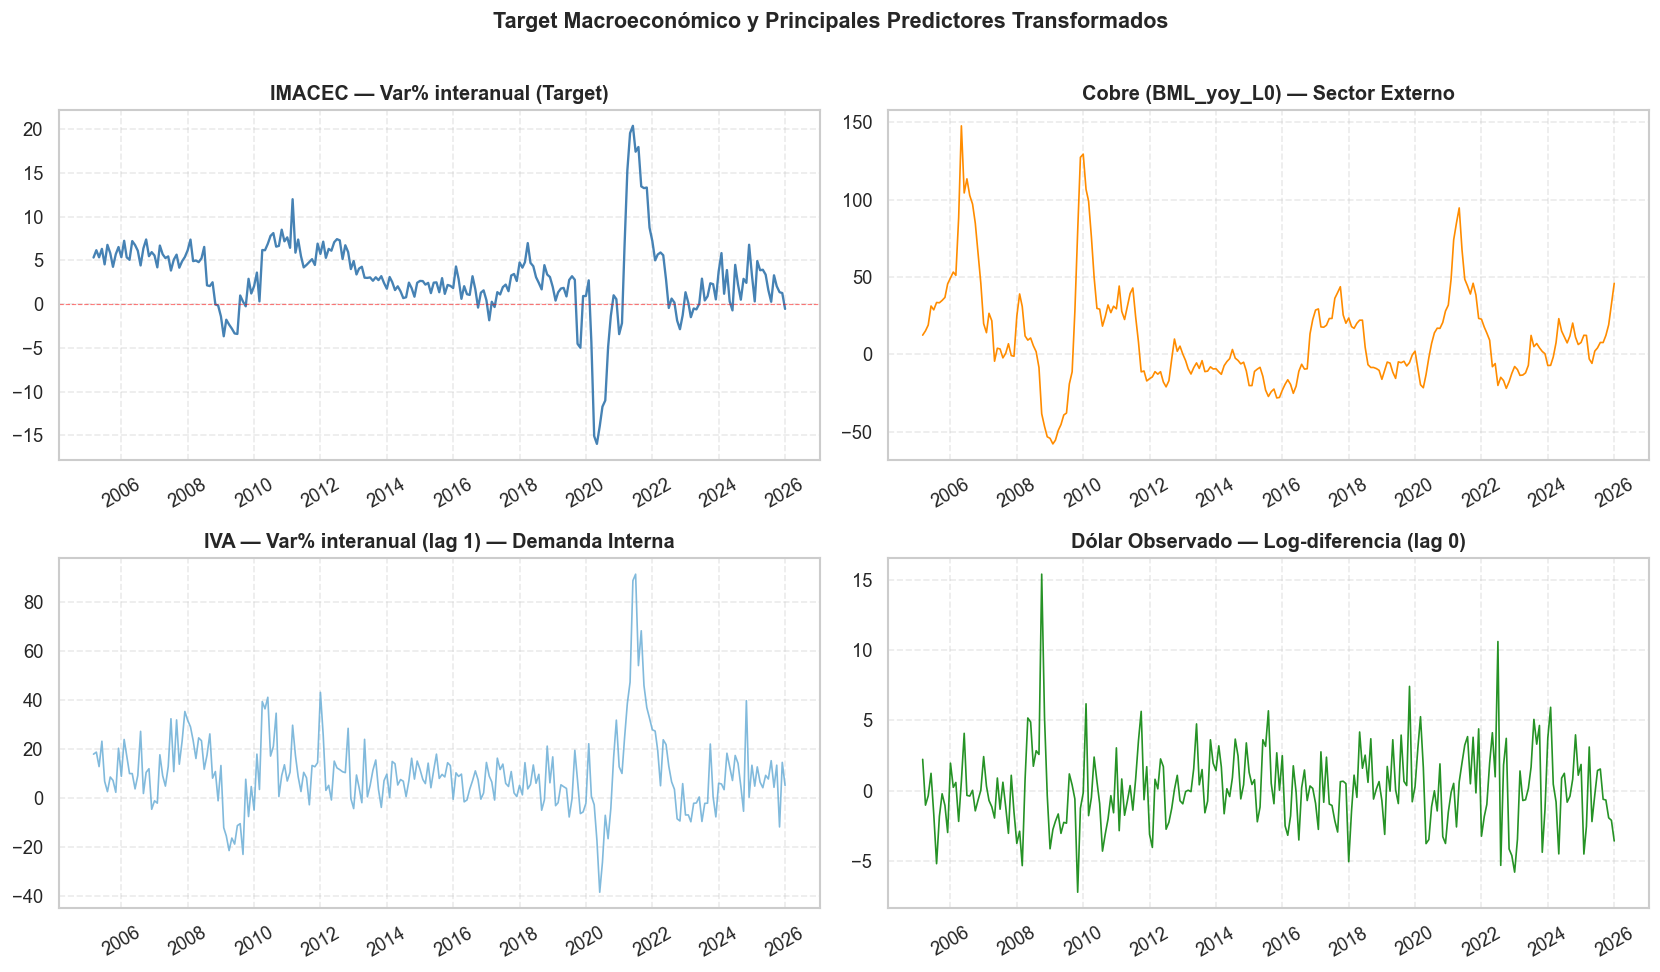

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1. Target: IMACEC
axes[0, 0].plot(
    df['fecha'], df['IMACEC_yoy'], linewidth=1.4, color='steelblue'
)
axes[0, 0].axhline(0, color='red', linewidth=0.7, linestyle='--', alpha=0.5)
axes[0, 0].set_title('IMACEC — Var% interanual (Target)', fontweight='bold')

# 2. Sector Externo: Precio del Cobre (si tenés BML_log_diff_L0 o BML_yoy_L0)
col_cobre = (
    'BML_yoy_L0'
    if 'BML_yoy_L0' in df.columns
    else (
        'BML_log_diff_L0'
        if 'BML_log_diff_L0' in df.columns
        else [c for c in df.columns if 'BML' in c][0]
    )
)
axes[0, 1].plot(df['fecha'], df[col_cobre], linewidth=1, color='darkorange')
axes[0, 1].set_title(
    f'Cobre ({col_cobre}) — Sector Externo', fontweight='bold'
)

# 3. Consumo / Actividad Doméstica: IVA
axes[1, 0].plot(
    df['fecha'], df['IVA_yoy_L1'], linewidth=1, alpha=0.85, color='#6baed6'
)
axes[1, 0].set_title(
    'IVA — Var% interanual (lag 1) — Demanda Interna', fontweight='bold'
)

# 4. Mercado Financiero / Cambiario: Dólar Observado
axes[1, 1].plot(
    df['fecha'],
    df['DÓLAR_OBS_log_diff_L0'],
    linewidth=1,
    alpha=0.85,
    color='green',
)
axes[1, 1].set_title(
    'Dólar Observado — Log-diferencia (lag 0)', fontweight='bold'
)

for ax in axes.flatten():
  ax.tick_params(axis='x', rotation=30)
  ax.xaxis.set_major_locator(mdates.YearLocator(2))
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
  ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(
    'Target Macroeconómico y Principales Predictores Transformados',
    fontsize=13,
    fontweight='bold',
    y=1.01,
)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento

Se construye un `Pipeline` de scikit-learn con `StandardScaler` seguido del modelo. Esto garantiza que el escalado se recalcula en cada iteración del backtesting usando **solo datos de entrenamiento**, evitando data leakage.

In [44]:
tscv = TimeSeriesSplit(n_splits=TSCV_SPLITS)


def make_pipelines():
    return {
        'LassoCV': Pipeline([
            ('scaler', StandardScaler()),
            ('model', LassoCV(alphas=ALPHA_GRID, cv=tscv, max_iter=20000, random_state=42, n_jobs=-1))
        ]),
        'RidgeCV': Pipeline([
            ('scaler', StandardScaler()),
            ('model', RidgeCV(alphas=ALPHA_GRID))
        ]),
    'Red_Neuronal_MLP': Pipeline([
        ('scaler', StandardScaler()),
        (
            'model',
            MLPRegressor(
                hidden_layer_sizes=(16, 8),
                activation='relu',
                solver='adam',
                alpha=0.05,
                max_iter=500,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
                random_state=42,
            ),
        ),
    ]),
  }

print(f'TimeSeriesSplit con {TSCV_SPLITS} folds para CV interna.')
print(f'Grilla de alphas: {len(ALPHA_GRID)} valores en [{ALPHA_GRID.min():.4f}, {ALPHA_GRID.max():.1f}]')
print(f'l1_ratio (ElasticNet): {L1_RATIOS}')
print('Pipelines definidos: LassoCV, RidgeCV, ElasticNetCV')

TimeSeriesSplit con 5 folds para CV interna.
Grilla de alphas: 50 valores en [0.0001, 100.0]
l1_ratio (ElasticNet): [0.1, 0.5, 0.7, 0.9, 0.99]
Pipelines definidos: LassoCV, RidgeCV, ElasticNetCV


## 5. Benchmarks

- **Naive:** $\hat{y}_t = y_{t-1}$ (la variación interanual del mes anterior)
- **Expectativas de mercado:** `EXP_IMACEC` para IMACEC total, `EXP_IMACEC_NO_MIN` para IMACEC no minero

In [45]:
def compute_benchmarks(df, yoy_col, benchmark_col, min_train):
    """
    Calcula naive y expectativas de mercado en espacio YoY (var% interanual).
    `yoy_col` debe ser la columna '{target}_yoy'. La conversión a delta para métricas
    se hace en evaluate_predictions según METRIC_TARGET_SPACE.
    """
    results = []
    for t in range(min_train, len(df)):
        row = {
            'fecha': df['fecha'].iloc[t],
            'actual': df[yoy_col].iloc[t],
            'naive': df[yoy_col].iloc[t - 1],
        }
        if benchmark_col in df.columns:
            bm_val = df[benchmark_col].iloc[t]
            row['mercado'] = bm_val if pd.notna(bm_val) else np.nan
        else:
            row['mercado'] = np.nan
        results.append(row)
    return pd.DataFrame(results)


print('Función de benchmarks definida.')

Función de benchmarks definida.


## 6. Modelado — Backtesting con Expanding Window

Para cada target y cada modelo, se entrena iterativamente:
- En cada paso $t$, se usa toda la historia disponible $[0, t)$ para entrenar.
- Se predice el punto $t$ (horizonte $h = 1$).
- El `StandardScaler` se recalcula en cada iteración dentro del `Pipeline`.

In [46]:
def run_backtest(df, target_col, feature_cols, min_train, model_names=['LassoCV', 'RidgeCV']):
    X = df[feature_cols].values
    y = df[target_col].values
    
    predictions = {m: [] for m in model_names}
    actuals = []
    fechas = []
    
    total_iters = len(df) - min_train
    
    for t in range(min_train, len(df)):
        # Ventana expansiva: todo el pasado hasta t-1 para entrenar, predecir t
        X_train, y_train = X[:t], y[:t]
        X_test = X[t:t+1]
        
        pipelines = make_pipelines()
        
        for name in model_names:
            pipe = pipelines[name]
            pipe.fit(X_train, y_train)
            predictions[name].append(pipe.predict(X_test)[0])
            
        actuals.append(y[t])
        fechas.append(df['fecha'].iloc[t])
        
    results_df = pd.DataFrame({'fecha': fechas, 'actual': actuals})
    for name in model_names:
        results_df[name] = predictions[name]
        
    return results_df


In [47]:
# ==============================================================================
# 6. EJECUCIÓN DEL BACKTESTING UNIFICADO
# ==============================================================================
target_col = 'IMACEC_yoy'
feature_cols = feature_cols_common + feature_cols_target['IMACEC']

print(f"Ejecutando backtesting temporal sobre {target_col}...")
modelos_a_evaluar = ['LassoCV', 'RidgeCV', 'Red_Neuronal_MLP']

# Corre los 3 modelos en la misma pasada
results_df = run_backtest(
    df, 
    target_col=target_col, 
    feature_cols=feature_cols, 
    min_train=MIN_TRAIN, 
    model_names=modelos_a_evaluar
)

# Incorporación de Benchmarks
eval_start = MIN_TRAIN
results_df['naive'] = df[target_col].shift(1).iloc[eval_start:].values

if 'EXP_IMACEC' in df.columns:
    results_df['mercado'] = df['EXP_IMACEC'].iloc[eval_start:].values
else:
    results_df['mercado'] = np.nan

print(f"Backtesting completado: {len(results_df)} meses evaluados fuera de muestra.")

Ejecutando backtesting temporal sobre IMACEC_yoy...
Backtesting completado: 191 meses evaluados fuera de muestra.


## 7. Evaluación

**Configuración modular (celda de configuración):** `TRAIN_TARGET_SPACE` (`'yoy'` o `'delta'`) define el target del modelo; `METRIC_TARGET_SPACE` define en qué espacio se calculan **MAE / RMSE / R² / DM** (si difiere del entrenamiento, las predicciones se convierten con `actual_prev_yoy`). Los benchmarks **naive** y **mercado** se definen siempre en **YoY** y se convierten a delta solo si `METRIC_TARGET_SPACE='delta'`.

Se comparan los modelos penalizados (full y **LassoCV_AR** solo con rezagos del target), **naive** y **expectativas de mercado** usando:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **R²** (Coeficiente de determinación)
- **Directional Accuracy**: acierto en la dirección del **cambio mes a mes del YoY** (misma lógica que antes: \(\operatorname{sign}(y^{yoy}_t-y^{yoy}_{t-1})\) vs \(\operatorname{sign}(\hat{y}^{yoy}_t-y^{yoy}_{t-1})\), con \(\hat{y}^{yoy}\) reconstruido si el modelo predijo en delta).
- **Test Diebold–Mariano** (pérdida MAE en `METRIC_TARGET_SPACE`, varianza HAC/Newey–West): contraste vs naive, vs mercado, y (si está activo el rezago propio) vs LassoCV_AR y fila LassoCV_AR vs naive.

In [48]:
# ==============================================================================
# 7. TABLA DE EVALUACIÓN Y TEST DE DIEBOLD-MARIANO
# ==============================================================================
from scipy.stats import norm

# --- 7.1 Métricas Descriptivas de Pronóstico ---
def get_metrics_table(results_df, df_full, eval_start_idx):
  # Excluir columnas que no sean predicciones
  ignore_cols = {'fecha', 'actual', 'prev'}
  model_cols = [c for c in results_df.columns if c not in ignore_cols]

  prev_y = df_full['IMACEC_yoy'].shift(1).iloc[eval_start_idx:].values
  metrics = []

  for col in model_cols:
    sub = results_df[[col, 'actual']].copy()
    sub['prev'] = prev_y
    sub = sub.dropna()

    if len(sub) == 0:
      continue

    y_t, y_p, p_t = sub['actual'].values, sub[col].values, sub['prev'].values
    dir_acc = (np.sign(y_t - p_t) == np.sign(y_p - p_t)).mean() * 100

    metrics.append({
        'Modelo': col,
        'MAE': mean_absolute_error(y_t, y_p),
        'RMSE': np.sqrt(mean_squared_error(y_t, y_p)),
        'R²': r2_score(y_t, y_p),
        'Dir. Accuracy (%)': dir_acc,
        'N': len(sub),
    })

  return pd.DataFrame(metrics).set_index('Modelo')

# --- 7.2 Test de Diebold-Mariano (Pérdida Absoluta / MAE con Newey-West) ---
def diebold_mariano_test(y_true, pred_focal, pred_ref, maxlags=3):
    """
    H0: Ambos modelos tienen igual precisión predictiva out-of-sample.
    d_t = |e_focal| - |e_ref|. 
    Un d_mean < 0 con p-valor < 0.05 indica que el modelo focal es significativamente mejor.
    """
    d = np.abs(y_true - pred_focal) - np.abs(y_true - pred_ref)
    n = len(d)
    d_mean = np.mean(d)
    
    # Varianza de largo plazo con pesos de Bartlett (Newey-West)
    gamma0 = np.var(d, ddof=0)
    gamma_sum = 0.0
    for l in range(1, maxlags + 1):
        weight = 1.0 - (l / (maxlags + 1))
        gamma_l = np.mean((d[l:] - d_mean) * (d[:-l] - d_mean))
        gamma_sum += 2.0 * weight * gamma_l
        
    se = np.sqrt(max(1e-8, (gamma0 + gamma_sum)) / n)
    z_stat = d_mean / se
    p_value = 2.0 * (1.0 - norm.cdf(abs(z_stat)))
    
    return d_mean, z_stat, p_value

# --- 7.3 Ejecución y Reporte ---
metrics_summary = get_metrics_table(results_df, df, MIN_TRAIN)
print("="*65)
print("TABLA COMPARATIVA DE DESEMPEÑO OUT-OF-SAMPLE (YoY %)")
print("="*65)
display(metrics_summary.round(3))

# Contrastes de significancia estadística
benchmarks = ['naive']
if 'mercado' in results_df.columns and results_df['mercado'].notna().sum() > 0:
    benchmarks.append('mercado')

dm_records = []
for model in ['LassoCV', 'Red_Neuronal_MLP']:
    for bm in benchmarks:
        sub = results_df[['actual', model, bm]].dropna()
        d_mean, z, p_val = diebold_mariano_test(
            sub['actual'].values,
            sub[model].values,
            sub[bm].values
        )
        dm_records.append({
            'Contraste': f"{model} vs {bm}",
            'Dif. MAE': d_mean,
            'Estadístico Z': z,
            'P-Valor': p_val,
            'Mejora Significativa (p < 0.05)': "Sí" if (p_val < 0.05 and d_mean < 0) else "No"
        })

print("\n" + "="*65)
print("TEST DE DIEBOLD-MARIANO (SIGNIFICANCIA FRENTE A BENCHMARKS)")
print("="*65)
display(pd.DataFrame(dm_records).round(4))

TABLA COMPARATIVA DE DESEMPEÑO OUT-OF-SAMPLE (YoY %)


,MAE,RMSE,R²,Dir. Accuracy (%),N
Modelo,,,,,
LassoCV,1.423,2.098,0.802,70.681,191
RidgeCV,1.435,2.113,0.799,70.681,191
Red_Neuronal_MLP,1.641,2.524,0.714,64.398,191
naive,1.634,2.383,0.745,0.000,191
mercado,1.840,2.800,0.648,60.209,191



TEST DE DIEBOLD-MARIANO (SIGNIFICANCIA FRENTE A BENCHMARKS)


,Contraste,Dif. MAE,Estadístico Z,P-Valor,Mejora Significativa (p < 0.05)
0,LassoCV vs naive,-0.2107,-1.9765,0.0481,Sí
1,LassoCV vs mercado,-0.4165,-3.2910,0.0010,Sí
2,Red_Neuronal_MLP vs naive,0.0068,0.0559,0.9554,No
3,Red_Neuronal_MLP vs mercado,-0.1990,-1.6223,0.1047,No


## 8. Interpretabilidad — Coeficientes del Lasso

Se entrena un `LassoCV` sobre toda la muestra disponible para extraer los coeficientes finales. Se muestran las **Top 15 variables** más relevantes por magnitud absoluta.

El Lasso realiza selección automática de variables al forzar a cero los coeficientes de features poco relevantes, lo que permite identificar los predictores más informativos.

In [49]:
# ==============================================================================
# 8. INTERPRETABILIDAD: SELECCIÓN DE VARIABLES Y COEFICIENTES LASSO
# ==============================================================================
import re

# 1. Ajuste de LassoCV sobre la muestra disponible para evaluar importancia estructural
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_cols])
y_yoy = df[target_col].values

lasso_interpret = LassoCV(alphas=ALPHA_GRID, cv=tscv, max_iter=20000, random_state=42)
lasso_interpret.fit(X_scaled, y_yoy)

# 2. Limpieza de nombres técnicos para visualización clara
def format_feature_name(name):
    # Quita sufijos como _yoy_L1, _log_diff_L0
    clean = re.sub(r'_(yoy|log_diff|level|delta)_L\d+$', '', str(name))
    lag_match = re.search(r'L(\d+)$', str(name))
    lag_label = f" (lag {lag_match.group(1)})" if lag_match else ""
    return clean + lag_label

feature_names_clean = [format_feature_name(c) for c in feature_cols]

# 3. DataFrame de coeficientes estandarizados
df_coefs = pd.DataFrame({
    'Variable': feature_names_clean,
    'Coeficiente': lasso_interpret.coef_
})

# Filtrar variables activas (coeficiente != 0) y ordenar por magnitud absoluta
df_active = df_coefs[df_coefs['Coeficiente'] != 0].copy()
df_active['Magnitud'] = df_active['Coeficiente'].abs()
df_top = df_active.sort_values('Magnitud', ascending=True).tail(12)


In [50]:
from sklearn.inspection import permutation_importance
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Crear el pipeline de la Red Neuronal
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation='relu',
        solver='adam',
        alpha=0.05,
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=20,
        random_state=42
    ))
])

# 2. Entrenar el modelo con toda la muestra histórica
mlp_model.fit(df[feature_cols], df[target_col])

# 3. Calcular la importancia por permutación
result = permutation_importance(
    mlp_model, 
    df[feature_cols], 
    df[target_col], 
    n_repeats=10, 
    random_state=42, 
    scoring='neg_mean_absolute_error'
)

# 4. Extraer el top 12 de variables
df_mlp_imp = pd.DataFrame({
    'Variable': feature_names_clean,
    'Importancia': result.importances_mean
}).sort_values('Importancia', ascending=True).tail(12)

display(df_mlp_imp)

,Variable,Importancia
8,IPC (lag 1),0.066193
4,DÓLAR_OBS (lag 0),0.068883
21,d_estallido,0.072261
13,DÓLAR (lag 0),0.083675
12,BML (lag 0),0.097047
10,IMP_CIF (lag 1),0.136199
0,IVA (lag 1),0.153094
9,IMCE (lag 0),0.164498
22,d_covid,0.176696
14,SEGURO_CESANTIA (lag 0),0.218965


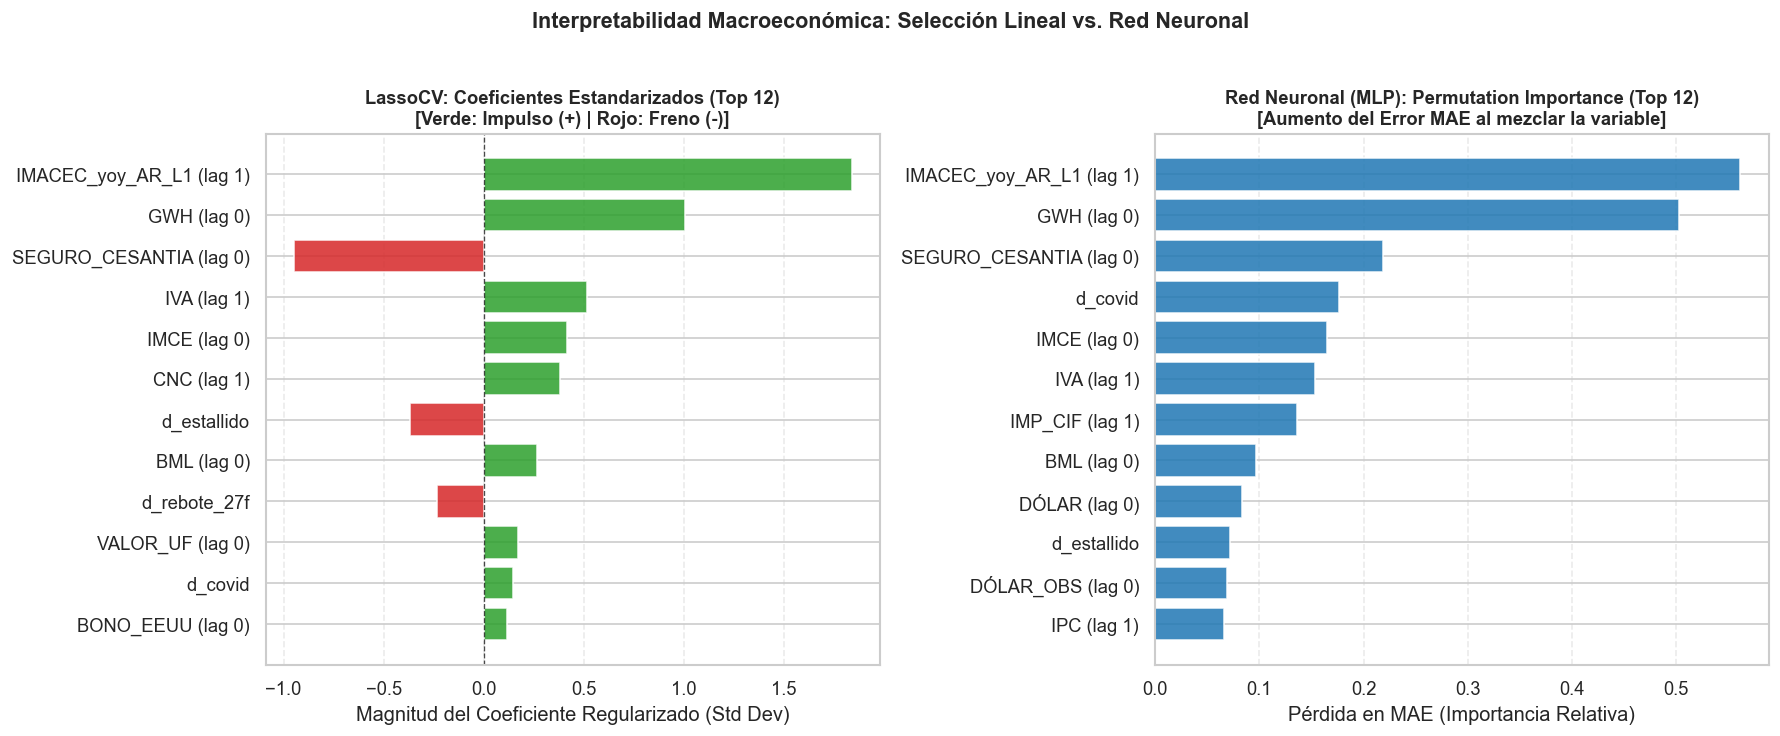

In [51]:
# ==============================================================================
# VISUALIZACIÓN: SELECCIÓN DE VARIABLES (LASSO vs. RED NEURONAL MLP)
# ==============================================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Coeficientes Lasso (Dirección y Magnitud Lineal)
colors_lasso = ['#2ca02c' if c > 0 else '#d62728' for c in df_top['Coeficiente']]
axes[0].barh(df_top['Variable'], df_top['Coeficiente'], color=colors_lasso, alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
axes[0].set_title(f'LassoCV: Coeficientes Estandarizados (Top {len(df_top)})\n[Verde: Impulso (+) | Rojo: Freno (-)]', 
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Magnitud del Coeficiente Regularizado (Std Dev)')
axes[0].grid(True, linestyle='--', alpha=0.4, axis='x')

# Panel 2: Permutation Importance MLP (Pérdida de Precisión No Lineal)
axes[1].barh(df_mlp_imp['Variable'], df_mlp_imp['Importancia'], color='#1f77b4', alpha=0.85)
axes[1].set_title(f'Red Neuronal (MLP): Permutation Importance (Top {len(df_mlp_imp)})\n[Aumento del Error MAE al mezclar la variable]', 
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pérdida en MAE (Importancia Relativa)')
axes[1].grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle('Interpretabilidad Macroeconómica: Selección Lineal vs. Red Neuronal', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('interpretabilidad_comparada.png', dpi=300)
plt.show()

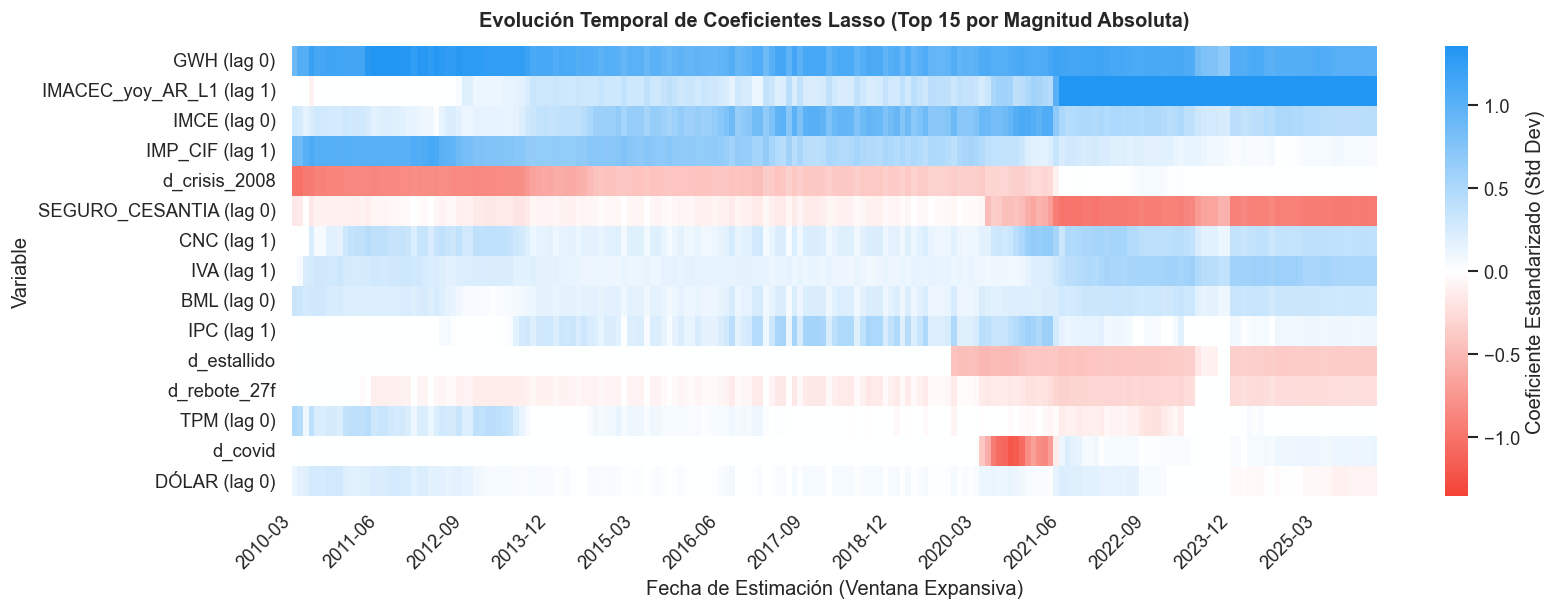

In [53]:
# ==============================================================================
# ACTIVACIÓN HISTÓRICA DE COEFICIENTES (LASSO EN EXPANDING WINDOW)
# ==============================================================================
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# 1. Configuración idéntica a la tesis
TOP_K_HEAT = 15
EPS_COEF = 1e-8
COEF_DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    'coef_lasso',
    ['#F44336', '#FFFFFF', '#2196F3'],  # Rojo: Freno (-) | Blanco: Cero | Azul: Impulso (+)
)

# 2. Extracción de coeficientes paso a paso en la ventana expansiva
X_full = df[feature_cols].values
y_full = df[target_col].values
dates_eval = pd.to_datetime(df['fecha'].iloc[MIN_TRAIN:].values)

coef_matrix = []

for t in range(MIN_TRAIN, len(df)):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_full[:t])
    y_tr = y_full[:t]
    
    lasso = LassoCV(alphas=ALPHA_GRID, cv=tscv, max_iter=20000, random_state=42, n_jobs=-1)
    lasso.fit(X_tr, y_tr)
    coef_matrix.append(lasso.coef_)

# 3. Construcción y selección de variables dominantes
coef_df = pd.DataFrame(coef_matrix, index=dates_eval, columns=feature_names_clean)

# Top K variables ordenadas por magnitud media absoluta
mean_abs = coef_df.abs().mean(axis=0).sort_values(ascending=False)
top_vars = mean_abs.head(TOP_K_HEAT).index.tolist()

# Matriz para heatmap (Variables en eje Y, Fechas en eje X)
Z = coef_df[top_vars].T

# Control robusto de escala (Percentil 98 para evitar distorsión por picos extremos)
vmax = float(np.nanpercentile(np.abs(Z.values), 98))
if vmax <= 0:
    vmax = 1e-6

# 4. Visualización del Heatmap Dinámico
fig, ax = plt.subplots(figsize=(14, max(4.5, TOP_K_HEAT * 0.35)))

sns.heatmap(
    Z, 
    ax=ax, 
    cmap=COEF_DIVERGING_CMAP, 
    center=0.0, 
    vmin=-vmax, 
    vmax=vmax,
    xticklabels=False, 
    cbar_kws={'label': 'Coeficiente Estandarizado (Std Dev)'}
)

# Configuración de fechas en el eje X
n_dates = Z.shape[1]
step = max(1, n_dates // 12)
xticks = np.arange(0, n_dates, step)
ax.set_xticks(xticks + 0.5)
ax.set_xticklabels([Z.columns[i].strftime('%Y-%m') for i in xticks], rotation=45, ha='right')

ax.set_title(f'Evolución Temporal de Coeficientes Lasso (Top {TOP_K_HEAT} por Magnitud Absoluta)', 
             fontsize=12, fontweight='bold', pad=12)
ax.set_ylabel('Variable')
ax.set_xlabel('Fecha de Estimación (Ventana Expansiva)')

plt.tight_layout()
plt.savefig('lasso_coef_heatmap_top15.png', dpi=300)
plt.show()

In [75]:
# ==============================================================================
# ENSAMBLE: BLENDING CONVEXO (LassoCV + Red Neuronal MLP)
# ==============================================================================
# Combinación 80/20 de ambos enfoques
results_df['Ensemble_Lasso_MLP'] = (
    0.8 * results_df['LassoCV'] + 0.2 * results_df['Red_Neuronal_MLP']
)

# Actualizar la tabla de métricas incorporando el ensamble
metrics_summary = get_metrics_table(results_df, df, MIN_TRAIN)
display(metrics_summary.round(3))

,MAE,RMSE,R²,Dir. Accuracy (%),N
Modelo,,,,,
LassoCV,1.423,2.098,0.802,70.681,191
RidgeCV,1.435,2.113,0.799,70.681,191
Red_Neuronal_MLP,1.641,2.524,0.714,64.398,191
naive,1.634,2.383,0.745,0.000,191
mercado,1.840,2.800,0.648,60.209,191
Ensemble_Lasso_MLP,1.415,2.118,0.798,70.157,191


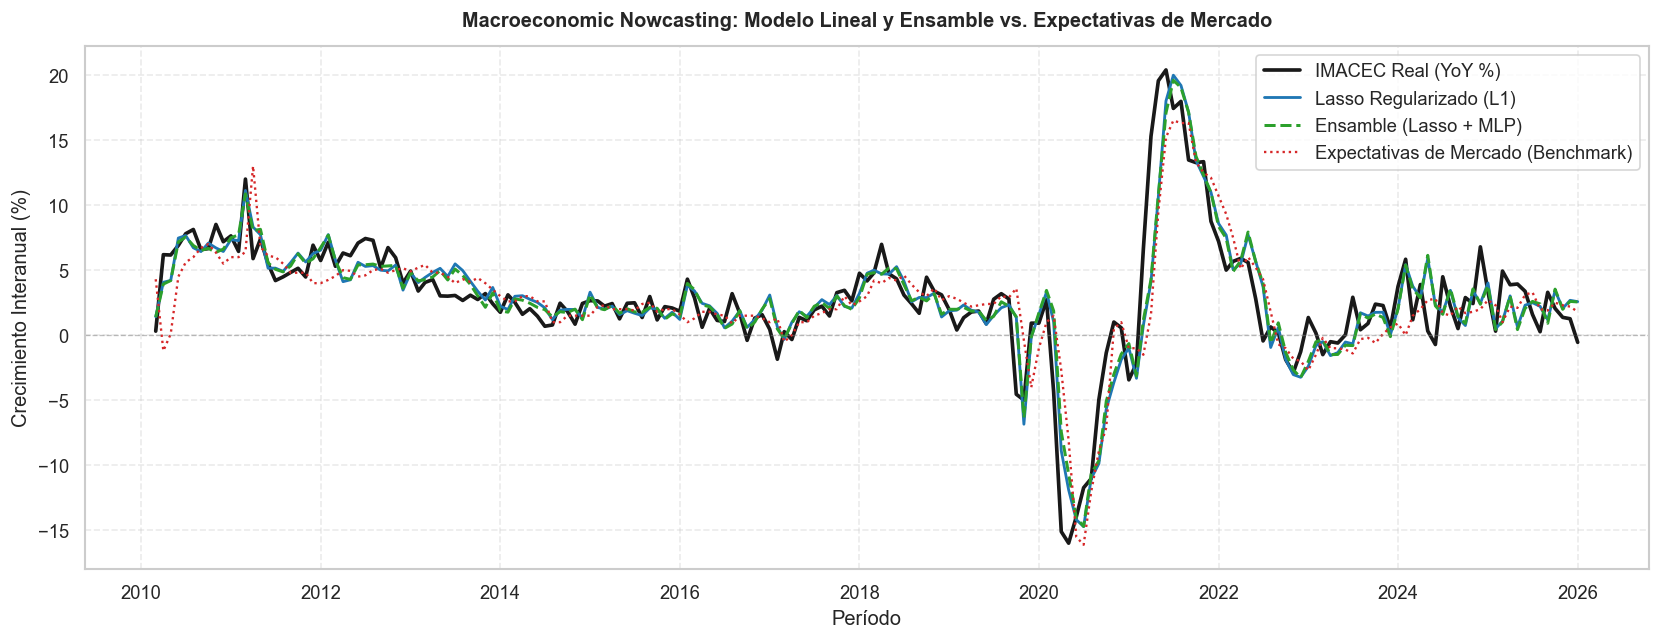

In [76]:
# ==============================================================================
# 8. VISUALIZACIÓN: PREDICCIÓN FUERA DE MUESTRA (OOS)
# ==============================================================================
plt.figure(figsize=(14, 5.5))

# 1. Serie Real
plt.plot(
    results_df['fecha'],
    results_df['actual'],
    label='IMACEC Real (YoY %)',
    color='black',
    linewidth=2.2,
    alpha=0.9,
)

# 2. Modelo Lineal Regularizado
plt.plot(
    results_df['fecha'],
    results_df['LassoCV'],
    label='Lasso Regularizado (L1)',
    color='#1f77b4',
    linewidth=1.7,
    linestyle='-',
)

# 3. Ensamble (Lasso + MLP)
plt.plot(
    results_df['fecha'],
    results_df['Ensemble_Lasso_MLP'],
    label='Ensamble (Lasso + MLP)',
    color='#2ca02c',
    linewidth=1.8,
    linestyle='--',
)

# 4. Benchmark de Mercado
plt.plot(
    results_df['fecha'],
    results_df['mercado'],
    label='Expectativas de Mercado (Benchmark)',
    color='#d62728',
    linewidth=1.4,
    linestyle=':',
)

plt.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
plt.title(
    'Macroeconomic Nowcasting: Modelo Lineal y Ensamble vs. Expectativas de'
    ' Mercado',
    fontsize=12,
    fontweight='bold',
    pad=12,
)
plt.ylabel('Crecimiento Interanual (%)')
plt.xlabel('Período')
plt.legend(frameon=True, facecolor='white', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.4)

plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('nowcasting_results.png', dpi=300)
plt.show()